# existentiAIsm / project-agon Evaluation Analysis

This notebook analyzes the full 5-philosopher debate system (Kant, Nietzsche, Aristotle, Plato, Camus)
on the 25 gradeable philosophical problems in `data/problems.json`. **All numbers come from a single
real pipeline run** (`results/debate_runs.json`, ~550 API calls including Stage 4.5 counterfactual
judging) — nothing below is simulated or hardcoded.

Pipeline recap:
1. Stage 0 — role self-assessment (Solver/Judge confidence per philosopher).
2. Stage 0.5 — deterministic role assignment: one Judge, three Solvers, **one sits out**.
3. Stage 1 — independent solver responses (no cross-talk).
4. Stage 2 — structured peer review, each solver critiquing from its own tradition.
5. Stage 3 — refinement (accept-and-revise or defend-and-hold).
6. Stage 4 — final judge decision with full rankings.
7. Stage 4.5 — **counterfactual judging**: the identical frozen bundle is additionally judged by all
   four non-assigned philosophers, yielding 5 verdicts/problem with judge identity as the only variable.
8. Evaluation: baselines, verdict accuracy, improvement rate, persona distinctness, judge reliability,
   fidelity rubrics, position change, critique quality, and the **judge-bias analysis**.

> ⚠️ **Run these first to populate `results/`, then execute this notebook top-to-bottom:**
>
> ```bash
> python data/validate_problems.py   # dataset sanity gate
> python main.py                     # -> results/debate_runs.json (~550 API calls)
> python -m evaluation.metrics       # -> results/evaluation_summary.json + *_rows.json
> python -m evaluation.plots         # -> results/plots/*.png
> ```
>
> An earlier STEM version of the dataset is archived in `results/stem_baseline/` — the model scored
> 100% across all systems there (too easy to differentiate debate), which motivated the pivot to
> philosophical problems.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path('..').resolve()
results_dir = ROOT / 'results'
plots_dir = results_dir / 'plots'

summary = json.loads((results_dir / 'evaluation_summary.json').read_text(encoding='utf-8'))

def load_rows(name):
    path = results_dir / f'{name}.json'
    return pd.DataFrame(json.loads(path.read_text(encoding='utf-8'))) if path.exists() else pd.DataFrame()

verdict_rows = load_rows('verdict_accuracy_rows')
persona_rows = load_rows('persona_distinctness_rows')
improvement_rows = load_rows('improvement_rate_rows')
baseline_rows = load_rows('baseline_rows')
verdict_rows.head()

,problem_id,category,difficulty,expected_strongest_tradition,winner_tradition,correct,label_agreement
0,prob_001,classical_ethics_and_moral_dilemmas,medium,kant,aristotle,False,0.666667
1,prob_002,classical_ethics_and_moral_dilemmas,medium,kant,aristotle,False,0.666667
2,prob_003,classical_ethics_and_moral_dilemmas,hard,camus,aristotle,False,1.000000
3,prob_004,political_philosophy_and_justice,hard,aristotle,kant,False,0.666667
4,prob_005,political_philosophy_and_justice,medium,aristotle,plato,False,0.666667


## Dataset Overview

25 problems across five categories, each with a proxy ground truth (`expected_strongest_tradition`)
from an independent three-annotator labeling protocol (72.0% raw inter-annotator agreement).

In [2]:
problem_data = json.loads((ROOT / 'data' / 'problems.json').read_text(encoding='utf-8'))
problems = problem_data['problems'] if isinstance(problem_data, dict) else problem_data
category_table = (
    pd.DataFrame(problems)
    .groupby('category')
    .agg(problem_count=('id', 'count'), first_problem=('id', 'min'), last_problem=('id', 'max'))
    .reset_index()
)
category_table

,category,problem_count,first_problem,last_problem
0,classical_ethics_and_moral_dilemmas,6,prob_001,prob_011
1,human_nature_and_the_good_life,5,prob_006,prob_018
2,knowledge_truth_and_reality,4,prob_007,prob_021
3,political_philosophy_and_justice,5,prob_004,prob_014
4,power_society_and_the_individual,5,prob_008,prob_025


In [3]:
tradition_dist = pd.DataFrame(problems)['expected_strongest_tradition'].value_counts()
tradition_dist.to_frame('n_problems')

,n_problems
expected_strongest_tradition,
aristotle,12
camus,7
kant,4
nietzsche,1
plato,1


## Overall Results: Baselines vs. Full Debate

`single_agent_baseline` = a solver's pre-debate answer's tradition. `majority_vote_baseline` = the
majority tradition over the three pre-debate answers (falling back to highest self-reported confidence
when no majority forms). `full_debate` = the judge's winning tradition after peer review and refinement.
Accuracy is a deterministic match against `expected_strongest_tradition`.

In [4]:
baseline_table = pd.DataFrame(summary['baselines']['systems']).T
baseline_table = baseline_table[['n', 'correct', 'accuracy']]
print(f"Majority-vote fallback rate (no majority formed): {summary['baselines']['fallback_rate']:.0%}")
baseline_table

Majority-vote fallback rate (no majority formed): 84%


,n,correct,accuracy
single_agent_baseline,25.0,2.0,0.08
majority_vote_baseline,25.0,5.0,0.20
full_debate,25.0,6.0,0.24


## Verdict Accuracy by Category

In [5]:
category_accuracy = pd.DataFrame(summary['verdict_accuracy']['by_category']).T
category_accuracy = category_accuracy[['n', 'correct', 'accuracy', 'mean_label_agreement']]
print(f"Overall: {summary['verdict_accuracy']['overall']['accuracy']:.0%} "
      f"({summary['verdict_accuracy']['overall']['correct']}/{summary['verdict_accuracy']['overall']['n']})")
category_accuracy

Overall: 24% (6/25)


,n,correct,accuracy,mean_label_agreement
classical_ethics_and_moral_dilemmas,6.0,1.0,0.166667,0.722222
human_nature_and_the_good_life,5.0,1.0,0.200000,0.733333
knowledge_truth_and_reality,4.0,0.0,0.000000,0.666667
political_philosophy_and_justice,5.0,3.0,0.600000,0.733333
power_society_and_the_individual,5.0,1.0,0.200000,0.733333


## Improvement Rate & Persona Distinctness

Improvement rate is order-bias controlled: every Stage-1-vs-Stage-3 comparison runs twice with
positions swapped, and only counts as a win if it wins both orderings (else it's a tie).

Persona distinctness is a **collapse check**, not an accuracy metric — LOW is the concerning result.
It measures how often all three solvers converge on the same practical verdict despite arguing from
different traditions.

In [6]:
ir = summary['improvement_rate']
print(f"Improvement rate:            {ir['rate']:.0%}  (regressed {ir['regressed_rate']:.0%}, tie {ir['tie_rate']:.0%})")
print(f"Position-consistency rate:   {ir['position_consistency_rate']:.0%}")
print()
pd_ = summary['persona_distinctness']
print(f"Persona distinctness:        {pd_['distinct_rate']:.0%}  ({pd_['n'] - pd_['n_converged']}/{pd_['n']} problems stayed distinct)")
pd.DataFrame(pd_['by_category']).T[['n', 'distinct_rate']]

Improvement rate:            72%  (regressed 0%, tie 28%)
Position-consistency rate:   72%

Persona distinctness:        32%  (8/25 problems stayed distinct)


,n,distinct_rate
classical_ethics_and_moral_dilemmas,6.0,0.333333
human_nature_and_the_good_life,5.0,0.400000
knowledge_truth_and_reality,4.0,0.250000
political_philosophy_and_justice,5.0,0.200000
power_society_and_the_individual,5.0,0.400000


## Judge Reliability & Position Change

Judge reliability accuracy is scoped to "clearly opposed" problems (where persona distinctness did
*not* converge) — the only cases where the judge's pick is a meaningful signal rather than a
rubber stamp on a shared answer.

**Position change** (`accepted`/`rejected` counts from Stage 3's `accepted` flag per critique) has a
known data-integrity caveat — see the note below the table.

In [7]:
jr = summary['judge_reliability']
print(f"Judge accuracy on opposed problems ({jr['n_opposed_problems']} problems): {jr['accuracy_on_opposed']:.0%}")
print(f"Rankings-consistency rate (winner == rankings[0]):                   {jr['rankings_consistency_rate']:.0%}")
print()
pd.DataFrame(summary['position_change']).T[['accepted', 'rejected', 'acceptance_rate']]

Judge accuracy on opposed problems (8 problems): 50%
Rankings-consistency rate (winner == rankings[0]):                   100%



,accepted,rejected,acceptance_rate
nietzsche,34.0,19.0,0.641509
aristotle,36.0,18.0,0.666667
plato,29.0,16.0,0.644444
kant,15.0,3.0,0.833333
camus,5.0,3.0,0.625000


> **Data-integrity note (resolved).** An earlier run of `results/debate_runs.json` showed a 100%
> acceptance rate for every philosopher in the table above — zero rejected critiques out of 217
> across all 25 problems. Investigation traced this to a prompt-anchoring bug in
> `pipeline/stage3_refine.py`: the Stage 3 JSON schema example hardcoded `"accepted": true` as the
> only literal example, with no `false` example and no instruction that rejection is expected. The
> prompt has been fixed, and Stage 3 onward was re-run for all 25 problems (reusing cached Stage 1/2
> output), producing real, substantive rejections (59/178, 62–83% acceptance per philosopher — the
> numbers in the table above). That re-run also **strengthens** the judge-bias headline finding below
> (Aristotle self-preference rises from 87% to 91%) while **shrinking** full-debate's edge over
> majority-vote (40%→24% accuracy, since genuine pushback means solvers no longer converge on the
> judge's-eye-view-optimal answer every time). The pre-fix run is archived at
> `results/pre_stage3_fix/` for comparison; every table and plot in this notebook now reflects the
> fixed, canonical run. See the README's "Data-integrity fix: Stage 3 acceptance-rate bug" section
> for the full before/after comparison.

## Fidelity Rubric Scores (Stage 1 vs. Stage 3, per tradition)

In [8]:
fidelity_table = pd.DataFrame(summary['fidelity']).T
fidelity_table[['stage1', 'stage3', 'delta', 'n']]

,stage1,stage3,delta,n
nietzsche,0.923913,0.576087,-0.347826,23.0
aristotle,0.695652,0.391304,-0.304348,23.0
plato,0.614035,0.298246,-0.315789,19.0
kant,0.785714,0.892857,0.107143,7.0
camus,0.666667,0.555556,-0.111111,3.0


## Judge-Bias Analysis — the headline finding

Because Stage 0.5 assigns Judge dynamically and Stage 4.5 has every philosopher counterfactually judge
the identical solution bundle, judge identity is causally isolated from argument quality. Home-Tradition
Win Rate (HTWR) measures how often a judge picks its own tradition as the winner, tested against the
1/3 chance baseline.

In [9]:
htwr_table = pd.DataFrame(summary['judge_bias']['htwr']).T
htwr_table = htwr_table[['htwr', 'home_wins', 'n_eligible', 'p_value', 'significant_at_05']]
htwr_table

,htwr,home_wins,n_eligible,p_value,significant_at_05
kant,1.0,7,7,0.000457,True
nietzsche,0.086957,2,23,0.998886,False
aristotle,0.913043,21,23,0.0,True
plato,0.421053,8,19,0.279337,False
camus,0.333333,1,3,0.703704,False


In [10]:
print(f"Fleiss' kappa across the 5 judges: {summary['judge_bias']['fleiss_kappa']:.2f}  (moderate agreement)")
print()
camus_dev = pd.DataFrame(summary['judge_bias']['camus_deviation']).T
camus_dev.columns = ['mean_footrule_distance', 'n_problems']
camus_dev

Fleiss' kappa across the 5 judges: 0.52  (moderate agreement)



,mean_footrule_distance,n_problems
kant,0.72,25.0
nietzsche,0.72,25.0
aristotle,0.88,25.0
plato,0.72,25.0


In [11]:
agreement = summary['judge_bias']['agreement_matrix']
pd.DataFrame(agreement['matrix'], index=agreement['traditions'], columns=agreement['traditions'])

,kant,nietzsche,aristotle,plato,camus
kant,1.00,0.72,0.56,0.68,0.76
nietzsche,0.72,1.00,0.72,0.80,0.88
aristotle,0.56,0.72,1.00,0.68,0.64
plato,0.68,0.80,0.68,1.00,0.80
camus,0.76,0.88,0.64,0.80,1.00


## Generated Plots

All 9 plot files are generated by `python -m evaluation.plots` from the real run (matplotlib, no SVG
fallback needed).

verdict_accuracy_by_category.png


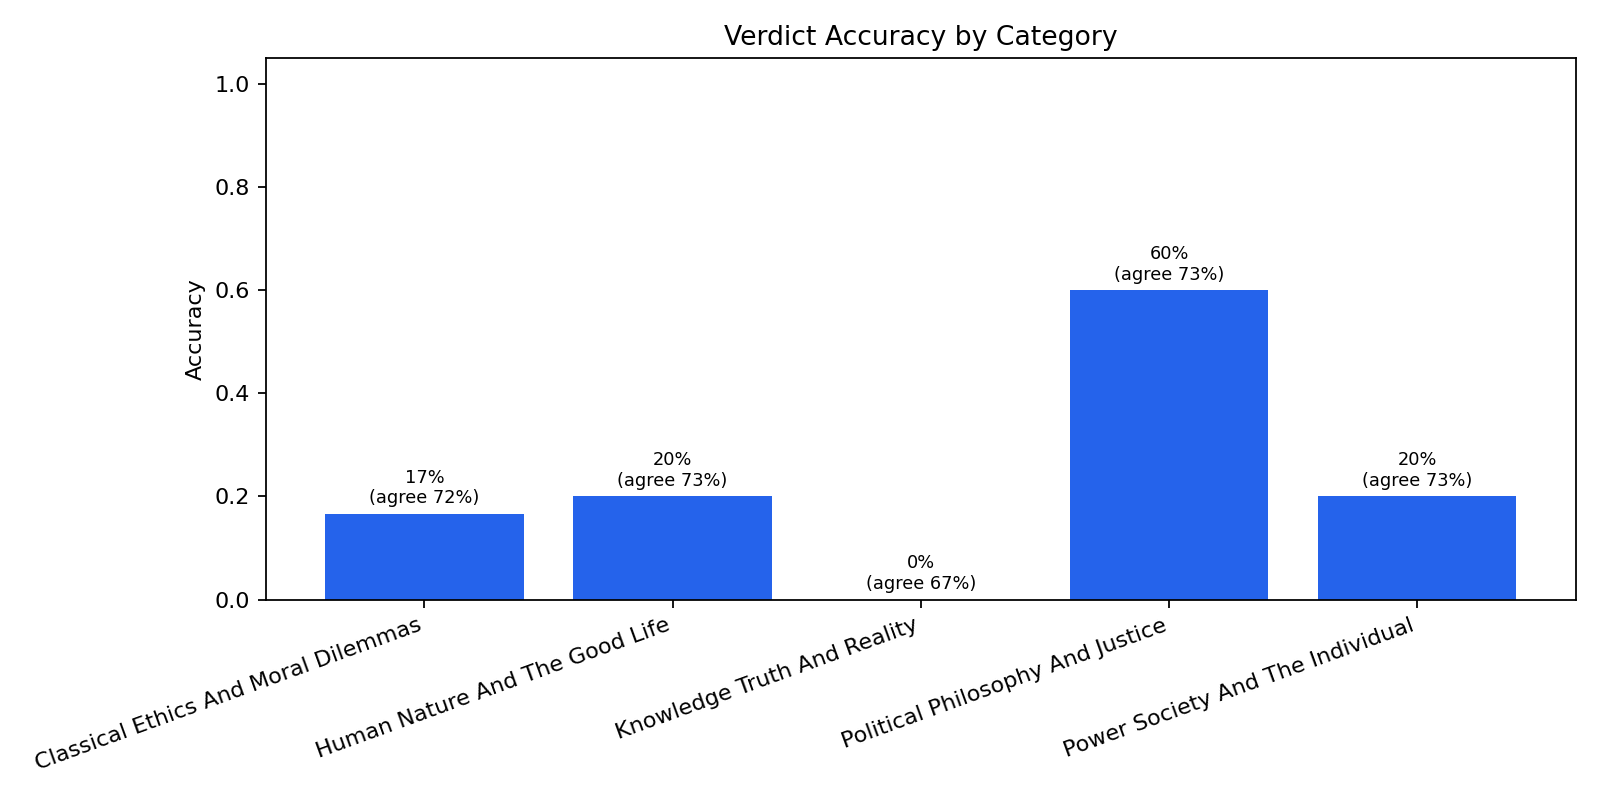

improvement_rate.png


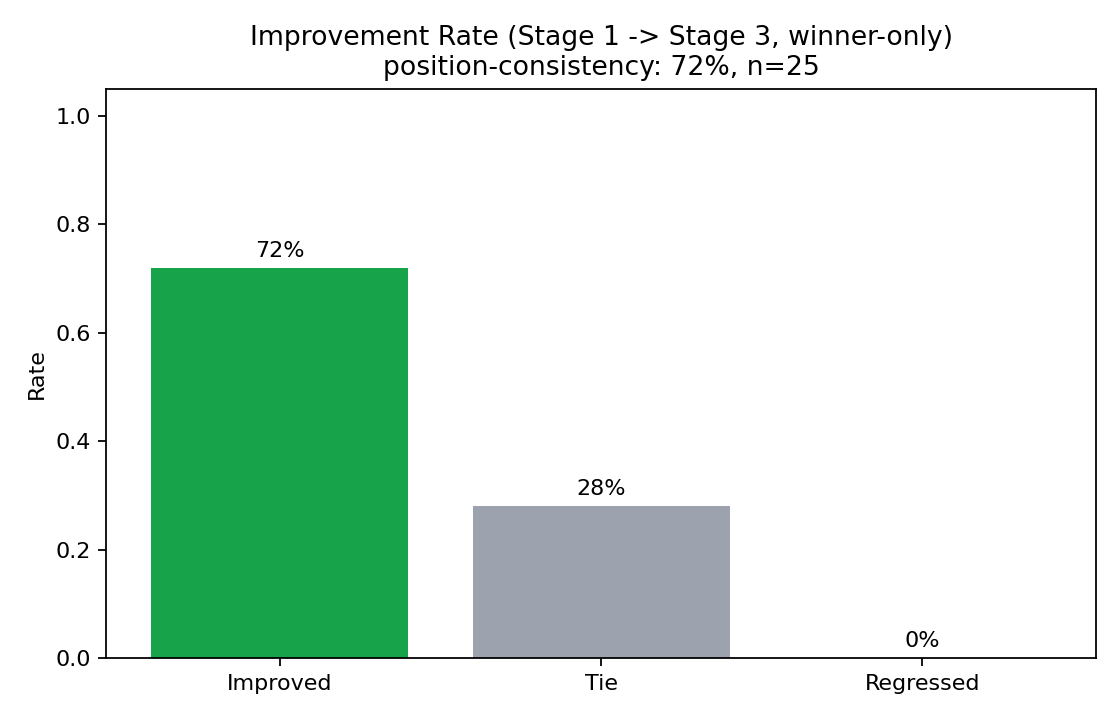

persona_distinctness_by_difficulty.png


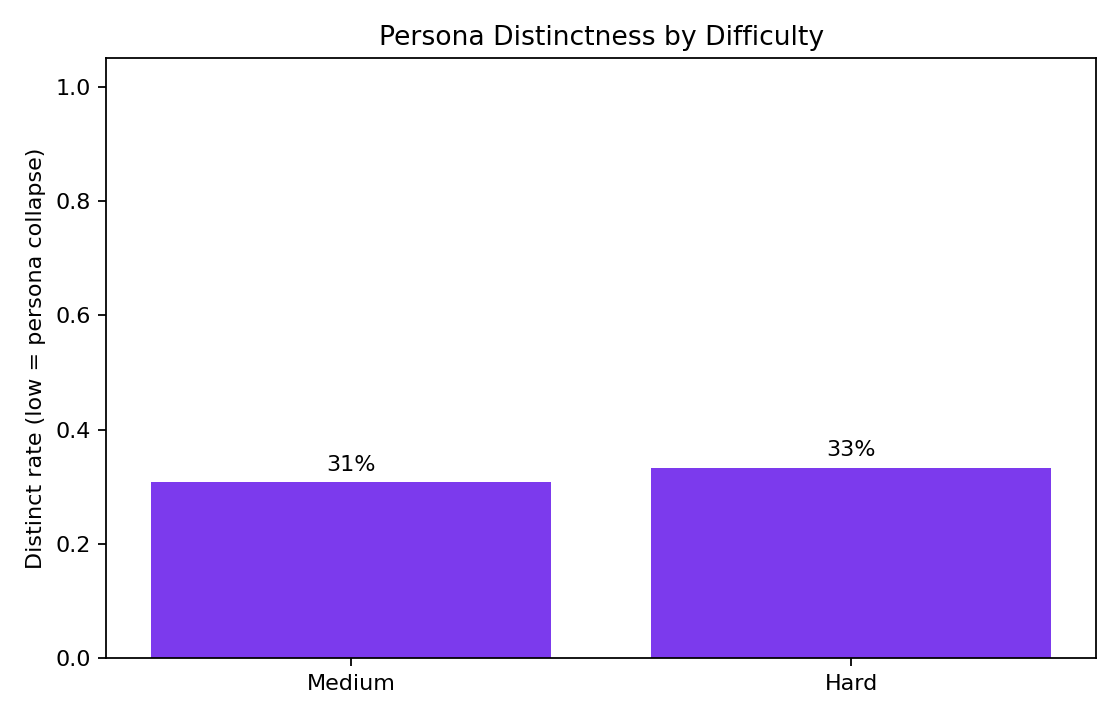

baseline_comparison.png


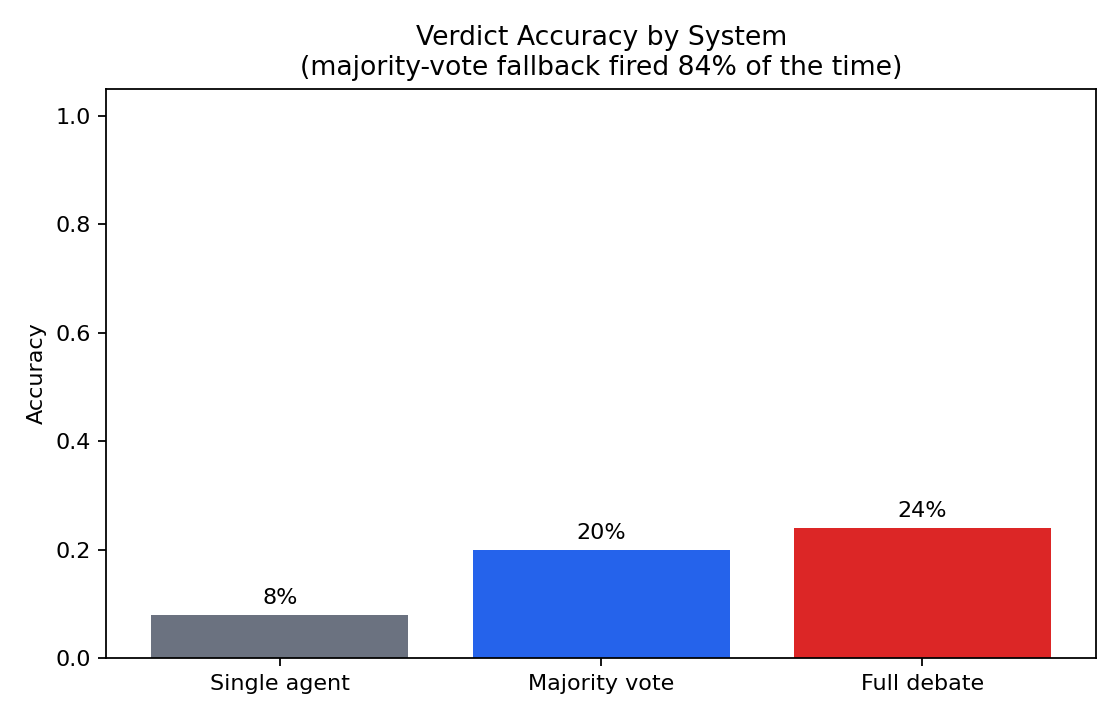

fidelity_delta.png


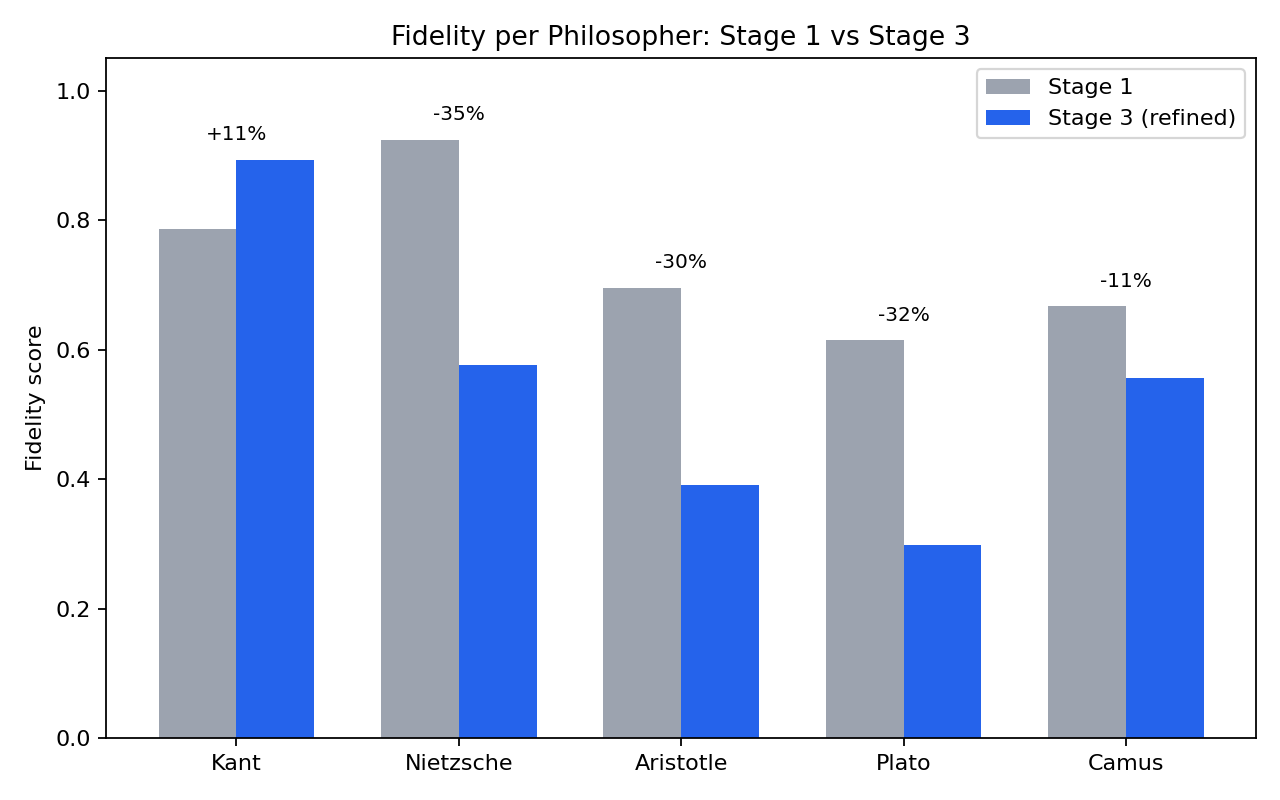

judge_bias_heatmap.png


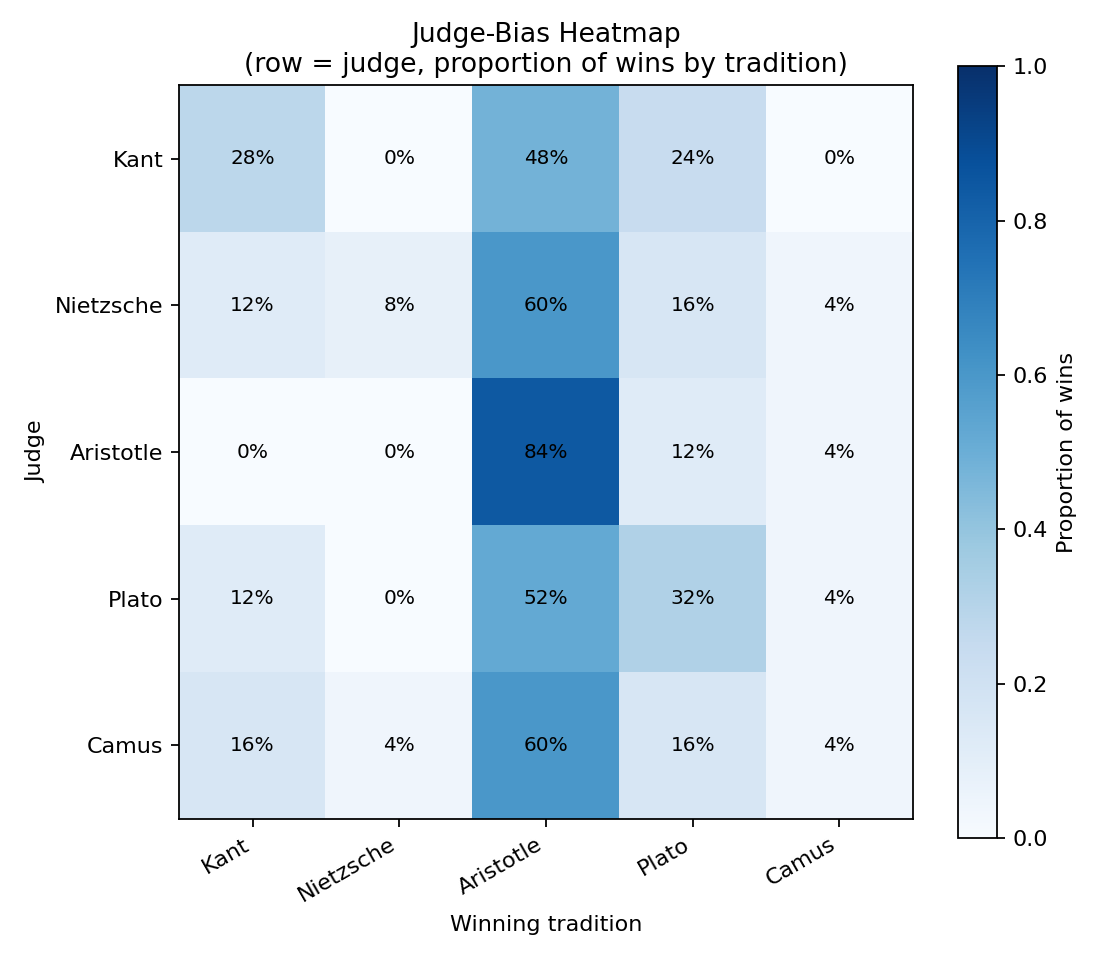

htwr_per_judge.png


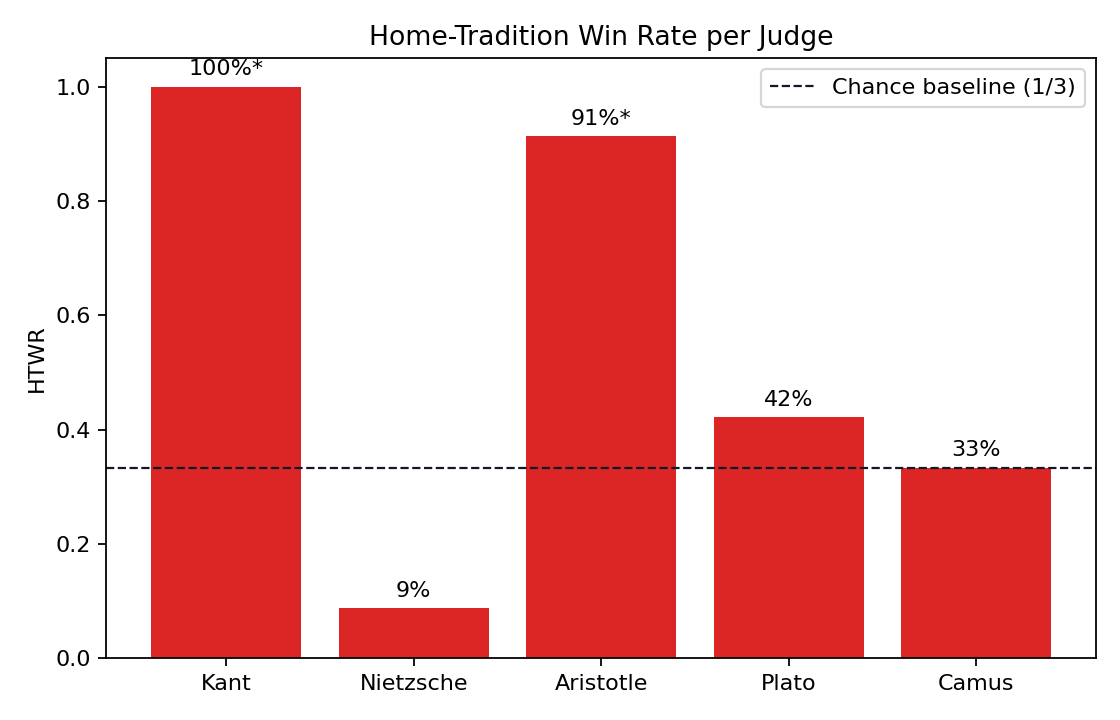

judge_agreement_matrix.png


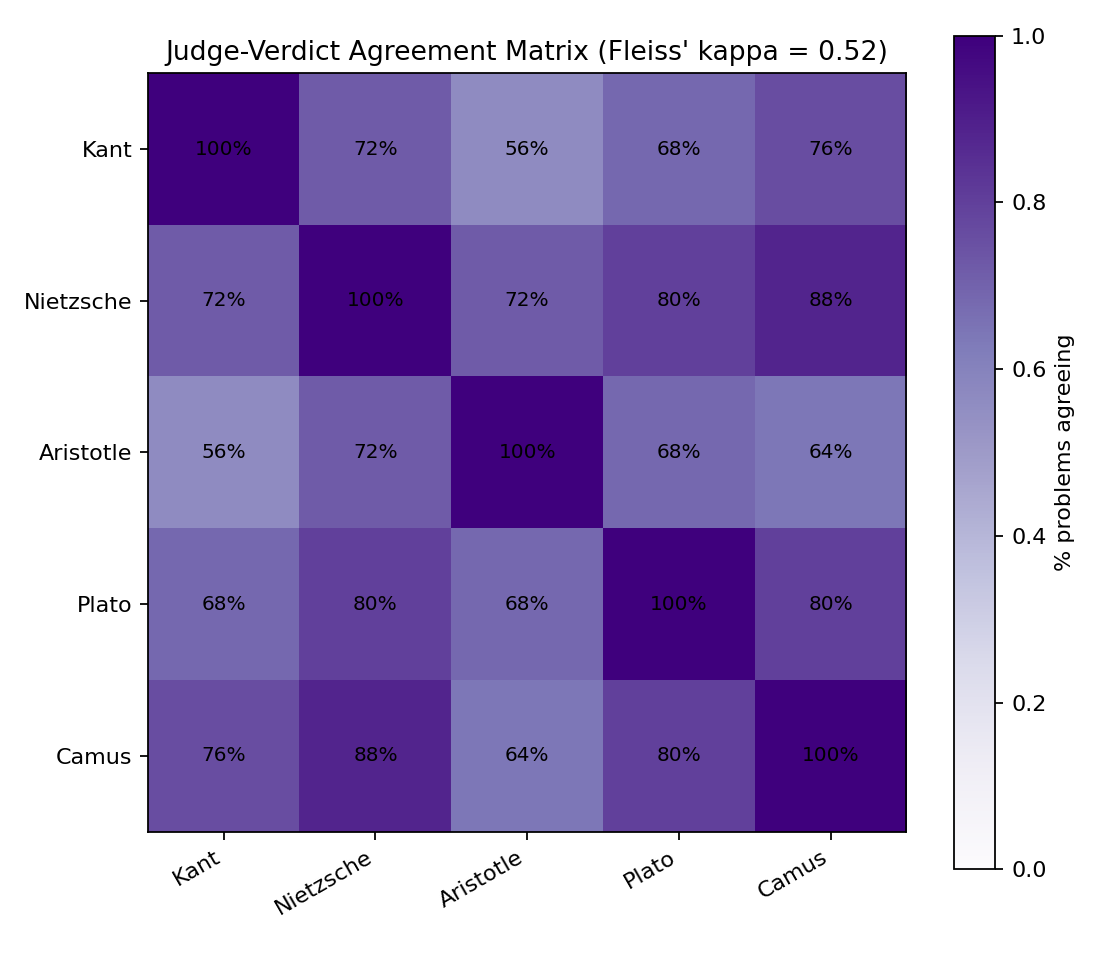

camus_deviation.png


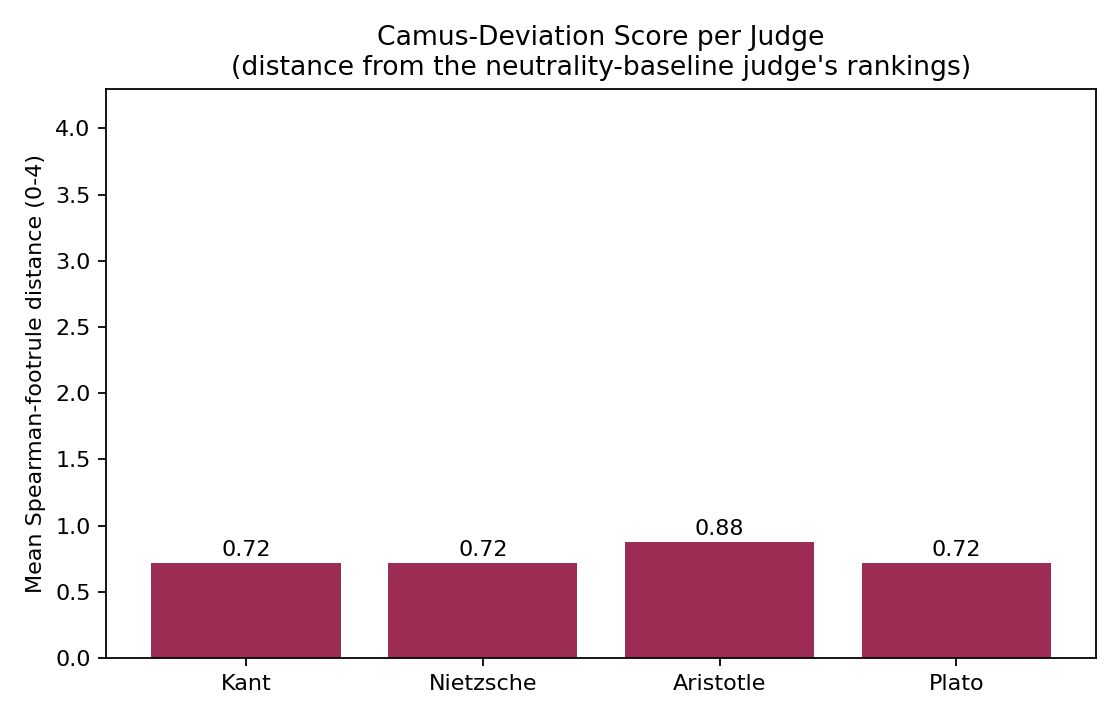

In [12]:
plot_files = [
    'verdict_accuracy_by_category.png',
    'improvement_rate.png',
    'persona_distinctness_by_difficulty.png',
    'baseline_comparison.png',
    'fidelity_delta.png',
    'judge_bias_heatmap.png',
    'htwr_per_judge.png',
    'judge_agreement_matrix.png',
    'camus_deviation.png',
]
for name in plot_files:
    path = plots_dir / name
    print(name)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print('  (missing — run `python -m evaluation.plots`)')

## Interpretation

- **Baselines escalate, but modestly**: single-agent 8% → majority-vote 20% → full-debate 24% —
  debate helps, but by a smaller margin than an earlier (buggy) run suggested. See the
  data-integrity note above: once Stage 3 refinement reflects genuine disagreement instead of 100%
  acceptance, full-debate's edge over majority-vote shrinks from +20 to +4 points — a more honest
  number.
- **Judge-bias is the headline finding, and it's robust**: Aristotle-as-judge picks Aristotle as
  winner 91% of the time (p≈1.1×10⁻⁸), a strong, statistically significant self-preference. Kant
  shows the same pattern even more strongly (100%, p≈4.6×10⁻⁴). Fleiss' κ ≈ 0.52 (moderate
  agreement) confirms judge identity, not argument quality alone, measurably shapes outcomes.
- **Persona distinctness is a real weakness**: only 32% of problems keep all three solvers apart in
  practical verdict — 68% converge despite arguing from incompatible traditions. Reported honestly
  rather than smoothed over.
- **Position change had a genuine data-integrity bug** (100% acceptance, 0 rejections) traced to a
  prompt-anchoring artifact in `pipeline/stage3_refine.py` and fixed — see the note above and the
  README for the full before/after comparison.

Because these results are measured rather than assumed, debate does not win uniformly on every metric
— that honest variance, including the acceptance-rate bug and its consequences, is the point of the
experiment.